In [15]:
import json
import os

os.environ["SPS_HOME"] = "/Users/z5114326/Documents/GitHub/python-fsps/src/fsps/libfsps"

import fsps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fsps.filters import FILTERS

In [16]:
dat_dir = "../data/"
mw_path = os.path.join(dat_dir, "mw_gcs/mw_gcs.csv")
mw_gcs = pd.read_csv(mw_path)

In [17]:
band_type = "SDSS"
bands = ["sdss_g", "sdss_z"]

In [18]:
assert (band_type == "JC") | (band_type == "SDSS"), "band_type must be JC or SDSS"

if band_type == "JC":
    compute_vega_mags = True
elif band_type == "SDSS":
    compute_vega_mags = False

sp = fsps.StellarPopulation(imf_type=2, zcontinuous=1, compute_vega_mags=compute_vega_mags)
sp.params["add_dust_emission"] = False
sp.params["dust1"] = 0
sp.params["dust2"] = 0
sp.params["fcstar"] = 0.0
sp.params["add_neb_continuum"] = False
sp.params["add_neb_emission"] = False
sp.params["add_agb_dust_model"] = False
sp.params["agb_dust"] = 0.0
sp.params["tpagb_norm_type"] = 0

In [39]:
ages = np.array(mw_gcs["age"])
fehs = np.array(mw_gcs["feh"])

msk = ~np.isnan(ages) | ~np.isnan(fehs)

ages = ages[msk]
fehs = fehs[msk]

In [ ]:
ssp_mags = []

for age, feh in zip(ages, fehs):
    sp.params["logzsol"] = feh
    ssp_mag = sp.get_mags(tage=age, bands=bands)
    ssp_mags.append(ssp_mag)
ssp_mags = np.array(ssp_mags)

(array([ 0.,  0.,  0., 17., 29., 22., 12.,  8.,  6.,  2.,  0.,  0.]),
 array([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6]),
 <BarContainer object of 12 artists>)

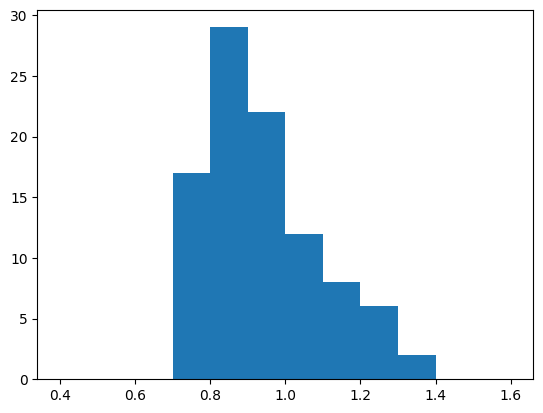

In [47]:
cols = ssp_mags[:, 0] - ssp_mags[:, 1]

bins = np.arange(0.4, 1.7, 0.1)
plt.hist(cols, bins=bins)